# Do African-built AI models actually work better on African languages?
## Evaluating Multilingual Models on Nigerian Languages
### A Statistical Investigation Using T-Tests

---

For decades, the most powerful AI language models were trained heavily
on English and to a lesser extent, French, German, Spanish, Chinese.
Languages with massive amounts of text on the internet.

Yoruba, Igbo and Hausa together have over 100 million speakers in Nigeria alone.
But in the training data of most AI models, they barely exist.

Researchers noticed this and they provided a solution.

They built smaller, focused models that were trained specifically on African language
data. Models like **AfriBERTa** and **AfroXLMR** were not trying to speak
every language on earth. They were trying to actually speak African languages
well.

But here is the question nobody answers with data:

## Do they actually work better?

T-tests are carried out to prove whether any difference we find is real or just noise.

---

### Models

| Model | Type | Description |
|---|---|---|
| **XLM-RoBERTa** | General | Trained on 100 languages. Powerful. Not Africa-specific. |
| **AfriBERTa** | Specialist | Trained on 11 African languages. Smaller. Focused. |
| **AfroXLMR** | Specialist | Trained on African languages. Larger and newer than AfriBERTa. |

### The Languages
**Yoruba, Igbo and Hausa** — Nigeria's three most spoken indigenous languages.
Over 100 million speakers between them. Completely underrepresented in mainstream AI.

### The Questions
- T-Test 1: Does AfroXLMR significantly outperform XLM-RoBERTa?
- T-Test 2: Does AfriBERTa significantly outperform XLM-RoBERTa?
- T-Test 3: Between the two specialists — who actually wins?


---

## Step 1: Install and Import all dependencies

In [3]:
!pip install transformers scipy matplotlib seaborn openpyxl torch --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from transformers import pipeline
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('All imports successful!')

All imports successful!


## Step 2: Load and Prepare Data

### Data Source & Methodology

**Source:** AfriSenti dataset (shmuhammad/AfriSenti-twitter-sentiment on HuggingFace)

**Languages:** We evaluate on three of Nigeria's most widely spoken indigenous languages:
- **Yoruba**
- **Igbo**
- **Hausa**

**Data Collection:**
We downloaded the test split from AfriSenti for each language. The dataset contains Twitter posts labeled with sentiment: positive, negative, or neutral.

**Sample Size & Balance:**
To ensure a balanced evaluation, we selected **99 examples per language** (297 total), with **33 examples per sentiment class** (positive, negative, neutral). This equal distribution prevents one sentiment from dominating the results and ensures robust statistical testing.

**Important Note:** This is a small but diverse sample. Larger datasets would strengthen conclusions, but this size is appropriate for demonstration and initial hypothesis testing.

In [4]:
EXCEL_FILE = '/content/afrisenti_nigeria.xlsx'
SAMPLE_SIZE = 99  # examples per language

datasets_loaded = {}

xl = pd.ExcelFile(EXCEL_FILE)
print(f'Sheets found: {xl.sheet_names}')
print()

for sheet in xl.sheet_names:
    df = pd.read_excel(EXCEL_FILE, sheet_name=sheet)
    df = df.head(SAMPLE_SIZE)
    lang_name = sheet.lower()
    datasets_loaded[lang_name] = df
    print(f'Loaded {lang_name}: {len(df)} examples')

print(f'\nLanguages ready: {list(datasets_loaded.keys())}')

# Preview the data
print('Sample from Yoruba:')
print(datasets_loaded['yoruba'].head(5).to_string())

Sheets found: ['Yoruba', 'Igbo', 'Hausa']

Loaded yoruba: 99 examples
Loaded igbo: 99 examples
Loaded hausa: 99 examples

Languages ready: ['yoruba', 'igbo', 'hausa']
Sample from Yoruba:
  language                                                                                                                                tweet true_label
0   yoruba                                                                                                           kiní yìí ọ̀tá orun ní í ṣe   negative
1   yoruba                                                                            inú ilé ni jọ́ọ̀nù ti ń kiri obìi tirẹ̀ ó ga o mùmú ni wá   negative
2   yoruba                                                                                                 oga o ewo ni orin eku lori oro oselu   negative
3   yoruba  honestly i had this experience yesterday one brother sitting close will not allow me concentrate bọ̀bọ́ yẹn kàn ń gbá ni àfi bí epo   negative
4   yoruba                            

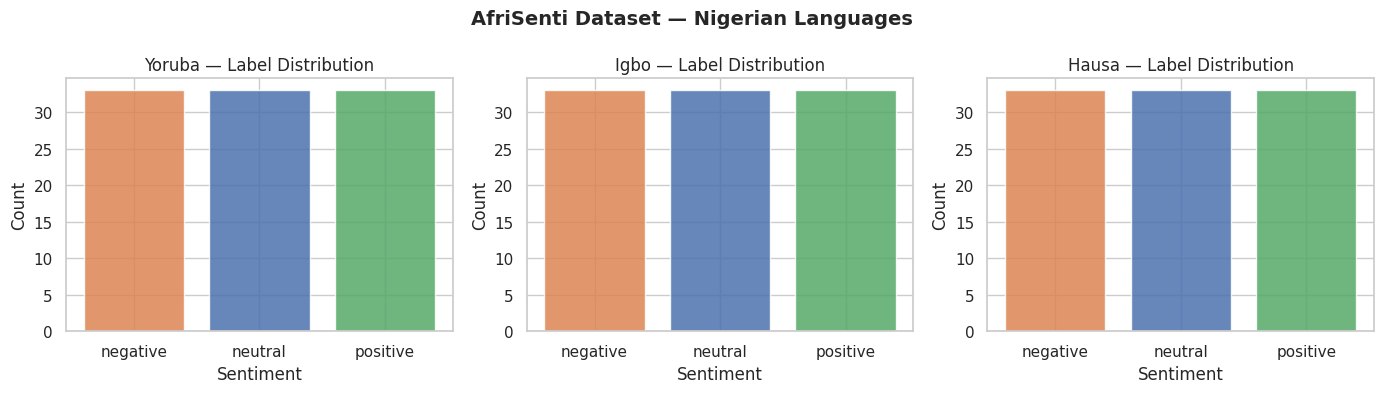

Chart saved!


In [5]:
# Label distribution across languages
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (lang_name, df) in zip(axes, datasets_loaded.items()):
    counts = df['true_label'].value_counts()
    ax.bar(counts.index, counts.values,
           color=['#DD8452', '#4C72B0', '#55A868'], alpha=0.85)
    ax.set_title(f'{lang_name.capitalize()} — Label Distribution', fontsize=12)
    ax.set_xlabel('Sentiment')
    ax.set_ylabel('Count')

plt.suptitle('AfriSenti Dataset — Nigerian Languages', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')

## Step 3: Load the Three Models

General multilingual models like XLM-RoBERTa are trained on 100+ languages including Yoruba, Igbo, and Hausa. But African-specific models like AfroXLMR and AfriBERTa were built *specifically* for African languages, with more focused training data.

We'll test both approaches and use t-tests to see if the difference is statistically significant—or just noise.

### Model Selection & Rationale

| Model | HuggingFace ID | Type | Why We Chose It |
|---|---|---|---|
| **XLM-RoBERTa** | facebook/xlm-roberta-large | General multilingual | Strong baseline. Trained on 100+ languages. Widely used in production. |
| **AfriBERTa** | castorini/afriberta_large | Africa-specific, smaller | Built specifically for 11 African languages. Compact. More efficient. |
| **AfroXLMR** | Davlan/afro-xlmr-large | Africa-specific, larger | Built for African languages. Larger model = potentially better performance. |

In [6]:
MODEL_CONFIGS = {
    'XLM-RoBERTa': 'cardiffnlp/twitter-xlm-roberta-base-sentiment',
    'AfriBERTa':   'Davlan/naija-twitter-sentiment-afriberta-large',
    'AfroXLMR':    'Davlan/afrisenti-twitter-sentiment-afroxlmr-large'
}

CANDIDATE_LABELS = ['positive', 'negative', 'neutral']

models = {}

for model_name, model_id in MODEL_CONFIGS.items():
    try:
        print(f'Loading {model_name}...')
        models[model_name] = pipeline(
            'text-classification',
            model=model_id
        )
        print(f'{model_name} ready!')
    except Exception as e:
        print(f'Could not load {model_name}: {e}')

print(f'\nModels loaded: {list(models.keys())}')

Loading XLM-RoBERTa...


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

AfroXLMR ready!

Models loaded: ['XLM-RoBERTa', 'AfriBERTa', 'AfroXLMR']


## Step 4: Run the Evaluation

### Evaluation Approach

We evaluate all three models on all three languages using **zero-shot sentiment classification**.

Here's the process:
1. For each model (XLM-RoBERTa, AfriBERTa, AfroXLMR)
2. For each language (Yoruba, Igbo, Hausa)
3. For each text example in that language
4. Pass the text to the model with three label options: *positive*, *negative*, *neutral*
5. Record what the model predicted, its confidence, and whether it was correct

### What We Measure

**Primary Metric: Accuracy**
- How many correct predictions out of total predictions?
- Formula: `(correct / total) × 100%`
- Range: 0.0 (all wrong) to 1.0 (all correct)
- Example: If the model gets 67 out of 99 correct → accuracy = 0.6768

**Secondary Data: Confidence Scores**
- Each prediction comes with a confidence score (0.0 to 1.0)
- Confidence = how sure is the model about its prediction?
- We capture this for later analysis (which models are overconfident? underconfident?)

**Detailed Predictions**
- We store every single prediction: the original text, the true label, what the model predicted,
  and the confidence score
- This lets us do error analysis later (which types of texts does each model get wrong?)

### Evaluation Process

For each of the **3 models × 3 languages = 9 combinations**, we:
1. Load that language's 99 text examples
2. Run the zero-shot classifier on each example
3. Compare predicted label to true label
4. Calculate accuracy for that model-language pair
5. Store all predictions for detailed analysis

**Total predictions:** 3 models × 3 languages × 99 examples = **891 predictions**

### What We Get Out

After this step, we'll have:
- **Results dictionary:** Accuracy score for each model-language combination
  - Example: `results['XLM-RoBERTa']['yoruba'] = 0.6768`
- **All predictions:** A detailed dataframe with every single prediction, true label,
  predicted label, and confidence
  - Used later for error analysis and visualization

### Why Capture Everything?

Accuracy alone tells us "did it work?" But the detailed predictions tell us *how* it worked:
- Which model is most confident?
- Which languages are hardest?
- What types of errors does each model make? (false positives vs false negatives)
- Is the model's confidence correlated with correctness?

This transforms the evaluation from a single number into a rich dataset for analysis.

In [7]:
import pandas as pd
from openpyxl import Workbook

def evaluate_model_detailed(model_pipeline, df, model_name, lang_name):
    """
    Run evaluation and return detailed results with every prediction.
    """
    rows = []
    correct = 0
    total = 0

    for _, row in df.iterrows():
        try:
            result = model_pipeline(str(row['tweet'])[:512])
            predicted = result[0]['label'].lower()
            confidence = round(result[0]['score'], 4)
            is_correct = predicted == row['true_label']
            if is_correct:
                correct += 1
            total += 1
            rows.append({
                'model':      model_name,
                'language':   lang_name,
                'tweet':      row['tweet'],
                'true_label': row['true_label'],
                'predicted':  predicted,
                'confidence': confidence,
                'correct':    '✅' if is_correct else '❌'
            })
        except Exception as e:
            continue

    accuracy = round(correct / total, 4) if total > 0 else 0.0
    return rows, accuracy


# Run full evaluation and collect all predictions
all_predictions = []
results = {}

for model_name, model_pipeline in models.items():
    results[model_name] = {}
    for lang_name, df in datasets_loaded.items():
        print(f'Evaluating {model_name} on {lang_name}...')
        rows, score = evaluate_model_detailed(
            model_pipeline, df, model_name, lang_name
        )
        results[model_name][lang_name] = score
        all_predictions.extend(rows)
        print(f'  Accuracy: {score:.4f}')

print('\nAll evaluations complete!')

Evaluating XLM-RoBERTa on yoruba...
  Accuracy: 0.4545
Evaluating XLM-RoBERTa on igbo...
  Accuracy: 0.3737
Evaluating XLM-RoBERTa on hausa...
  Accuracy: 0.4848
Evaluating AfriBERTa on yoruba...
  Accuracy: 0.7778
Evaluating AfriBERTa on igbo...
  Accuracy: 0.7576
Evaluating AfriBERTa on hausa...
  Accuracy: 0.7980
Evaluating AfroXLMR on yoruba...
  Accuracy: 0.7677
Evaluating AfroXLMR on igbo...
  Accuracy: 0.7172
Evaluating AfroXLMR on hausa...
  Accuracy: 0.7879

All evaluations complete!


In [8]:
OUTPUT_FILE = 'model_predictions.xlsx'
predictions_df = pd.DataFrame(all_predictions)

with pd.ExcelWriter(OUTPUT_FILE, engine='openpyxl') as writer:
    # Sheet 1 — all predictions together
    predictions_df.to_excel(writer, sheet_name='All Predictions', index=False)

    # One sheet per model
    for model_name in predictions_df['model'].unique():
        model_df = predictions_df[predictions_df['model'] == model_name]
        model_df.to_excel(writer, sheet_name=model_name, index=False)

    # Summary sheet
    results_df = pd.DataFrame(results).T
    results_df.to_excel(writer, sheet_name='Summary Scores')

print(f'Saved to {OUTPUT_FILE}')

# Results table
results_df = pd.DataFrame(results).T
print('Results Table (Accuracy Scores):')
print()
print(results_df.round(4).to_string())

# Download from Colab
from google.colab import files
files.download(OUTPUT_FILE)

Saved to model_predictions.xlsx
Results Table (Accuracy Scores):

             yoruba    igbo   hausa
XLM-RoBERTa  0.4545  0.3737  0.4848
AfriBERTa    0.7778  0.7576  0.7980
AfroXLMR     0.7677  0.7172  0.7879


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 5: Descriptive Statistics

### Why Descriptive Statistics Matter

Before we can test if differences are statistically significant, we need to understand
the **data itself**. Descriptive statistics answer basic questions:

- What is the average accuracy for each model on each language?
- How much do scores vary? (some languages harder than others?)
- Are African-specific models consistently better, or just sometimes?

These statistics form the **foundation** for the t-tests we'll run later.

### What We Calculate

**Mean Accuracy**
- The average performance: sum all accuracies, divide by number of languages
- This is what we'll compare between models using t-tests

**Standard Deviation (SD)**
- How spread out are the scores? How much variation across languages?
- Formula: measure of how far each score is from the mean


**Per-Model Summary**
- We create a summary table showing:
  - Mean accuracy per model
  - Standard deviation per model
  - Min and max scores
  - This lets us see patterns at a glance

### The Visualization: Accuracy Across Languages

A bar chart is created to show the accuracy for each model on each language:

In [9]:
lang_list = list(datasets_loaded.keys())

print('=== Descriptive Statistics ===')
print()

for model_name in results:
    scores = [results[model_name][l] for l in lang_list if l in results[model_name]]
    print(f'{model_name}:')
    print(f'  Mean accuracy  : {np.mean(scores):.4f}')
    print(f'  Std deviation  : {np.std(scores):.4f}')
    print(f'  Min score      : {min(scores):.4f}')
    print(f'  Max score      : {max(scores):.4f}')
    print()

=== Descriptive Statistics ===

XLM-RoBERTa:
  Mean accuracy  : 0.4377
  Std deviation  : 0.0469
  Min score      : 0.3737
  Max score      : 0.4848

AfriBERTa:
  Mean accuracy  : 0.7778
  Std deviation  : 0.0165
  Min score      : 0.7576
  Max score      : 0.7980

AfroXLMR:
  Mean accuracy  : 0.7576
  Std deviation  : 0.0297
  Min score      : 0.7172
  Max score      : 0.7879



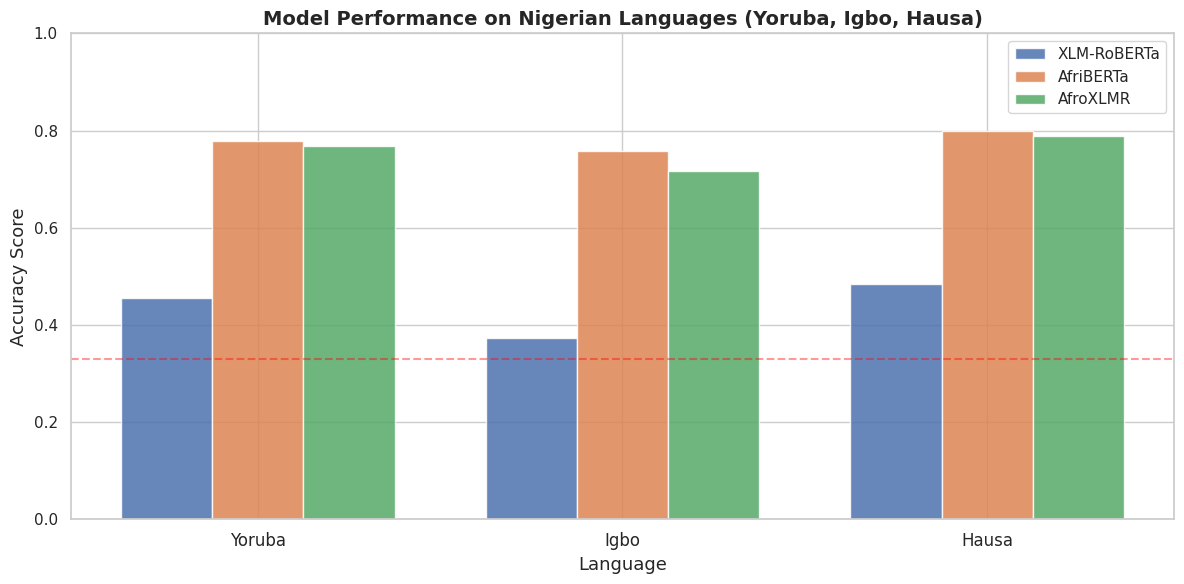

Chart saved!


In [10]:
# Visualization — Grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))

languages  = list(results_df.columns)
model_names = list(results_df.index)
x = np.arange(len(languages))
width = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']

for i, (model_name, color) in enumerate(zip(model_names, colors)):
    scores = [results_df.loc[model_name, lang] for lang in languages]
    ax.bar(x + i * width, scores, width,
           label=model_name, color=color, alpha=0.85)

ax.set_xlabel('Language', fontsize=13)
ax.set_ylabel('Accuracy Score', fontsize=13)
ax.set_title('Model Performance on Nigerian Languages (Yoruba, Igbo, Hausa)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels([l.capitalize() for l in languages], fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.0)
ax.axhline(y=0.33, color='red', linestyle='--', alpha=0.4, label='Random baseline')

plt.tight_layout()
plt.savefig('model_performance_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')

## Step 6: T-Test 1 — AfroXLMR vs XLM-RoBERTa
### Does AfroXLMR significantly outperform the general model?

XLM-RoBERTa = the general model trained on 100 languages scored 43.77% accuracy on average across Yoruba, Igbo and Hausa.

AfroXLMR = built specifically for African languages scored 75.76%.

> *Is this gap big enough and consistent enough that we can trust it
or could random chance explain it away?*


If the p-value is less than 0.05, the gap is real. If it is higher, we cannot prove anything.

**Null Hypothesis (H₀):** AfroXLMR does not perform significantly better than XLM-RoBERTa on Nigerian languages.

**Alternative Hypothesis (H₁):** AfroXLMR performs significantly better than XLM-RoBERTa on Nigerian languages.

**Significance level: α = 0.05**

In [11]:
afro_scores = [
    results['AfroXLMR'][l]
    for l in lang_list
    if l in results.get('AfroXLMR', {})
]

xlmr_scores = [
    results['XLM-RoBERTa'][l]
    for l in lang_list
    if l in results.get('XLM-RoBERTa', {})
]

print('AfroXLMR scores    :', [round(s, 4) for s in afro_scores])
print('XLM-RoBERTa scores :', [round(s, 4) for s in xlmr_scores])
print()
print(f'AfroXLMR mean      : {np.mean(afro_scores):.4f}')
print(f'XLM-RoBERTa mean   : {np.mean(xlmr_scores):.4f}')
print(f'Difference         : {np.mean(afro_scores) - np.mean(xlmr_scores):.4f}')

AfroXLMR scores    : [0.7677, 0.7172, 0.7879]
XLM-RoBERTa scores : [0.4545, 0.3737, 0.4848]

AfroXLMR mean      : 0.7576
XLM-RoBERTa mean   : 0.4377
Difference         : 0.3199


In [15]:
alpha = 0.05
t_stat_1, p_value_1 = stats.ttest_ind(afro_scores, xlmr_scores)

print('=' * 55)
print('T-TEST 1: AfroXLMR vs XLM-RoBERTa')
print('=' * 55)
print(f'T-statistic  : {t_stat_1:.4f}')
print(f'P-value      : {p_value_1:.4f}')
print()

if p_value_1 < alpha:
    print(f'p = {p_value_1:.4f} < {alpha}')
    print('RESULT: We REJECT the null hypothesis.')
    print('AfroXLMR IS significantly better than XLM-RoBERTa')
    print('on Nigerian languages. The difference is real.')
else:
    print(f'p = {p_value_1:.4f} >= {alpha}')
    print('RESULT: We FAIL TO REJECT the null hypothesis.')
    print('The difference between AfroXLMR and XLM-RoBERTa')
    print('is NOT statistically significant.')

T-TEST 1: AfroXLMR vs XLM-RoBERTa
T-statistic  : 8.1487
P-value      : 0.0012

p = 0.0012 < 0.05
RESULT: We REJECT the null hypothesis.
AfroXLMR IS significantly better than XLM-RoBERTa
on Nigerian languages. The difference is real.


## Step 7: T-Test 2 — AfriBERTa vs XLM-RoBERTa

AfriBERTa has fewer parameters, less compute, older architecture. AfriBERTa averaged
**77.78%**.

> *Does the smaller, older African-specific model significantly outperform
the general multilingual one?*

**Null Hypothesis (H₀):** AfriBERTa does not perform significantly better
than XLM-RoBERTa on Nigerian languages.

**Alternative Hypothesis (H₁):** AfriBERTa performs significantly better
than XLM-RoBERTa on Nigerian languages.

**Significance level: α = 0.05**

In [16]:
afriberta_scores = [
    results['AfriBERTa'][l]
    for l in lang_list
    if l in results.get('AfriBERTa', {})
]

print('AfriBERTa scores   :', [round(s, 4) for s in afriberta_scores])
print('XLM-RoBERTa scores :', [round(s, 4) for s in xlmr_scores])
print()
print(f'AfriBERTa mean     : {np.mean(afriberta_scores):.4f}')
print(f'XLM-RoBERTa mean   : {np.mean(xlmr_scores):.4f}')
print(f'Difference         : {np.mean(afriberta_scores) - np.mean(xlmr_scores):.4f}')

AfriBERTa scores   : [0.7778, 0.7576, 0.798]
XLM-RoBERTa scores : [0.4545, 0.3737, 0.4848]

AfriBERTa mean     : 0.7778
XLM-RoBERTa mean   : 0.4377
Difference         : 0.3401


In [17]:
t_stat_2, p_value_2 = stats.ttest_ind(afriberta_scores, xlmr_scores)

print('=' * 55)
print('T-TEST 2: AfriBERTa vs XLM-RoBERTa')
print('=' * 55)
print(f'T-statistic  : {t_stat_2:.4f}')
print(f'P-value      : {p_value_2:.4f}')
print()

if p_value_2 < alpha:
    print(f'p = {p_value_2:.4f} < {alpha}')
    print('RESULT: We REJECT the null hypothesis.')
    print('AfriBERTa IS significantly better than XLM-RoBERTa')
    print('on Nigerian languages.')
else:
    print(f'p = {p_value_2:.4f} >= {alpha}')
    print('RESULT: We FAIL TO REJECT the null hypothesis.')
    print('AfriBERTa is NOT significantly better than XLM-RoBERTa.')
    print('The general model holds its own against the specialist.')

T-TEST 2: AfriBERTa vs XLM-RoBERTa
T-statistic  : 9.6769
P-value      : 0.0006

p = 0.0006 < 0.05
RESULT: We REJECT the null hypothesis.
AfriBERTa IS significantly better than XLM-RoBERTa
on Nigerian languages.


## Step 8: T-Test 3 — AfroXLMR vs AfriBERTa

AfriBERTa outscored AfroXLMR on every single language.

- **Yoruba:** 77.78% vs 76.77%
- **Igbo:** 75.76% vs 71.72%
- **Hausa:** 79.80% vs 78.79%

But look closer at those numbers. The gaps are tiny. 1 percentage point. 4 percentage
points. We are talking about the difference of **one or two tweets** in a 99-tweet sample.

Maybe AfriBERTa got lucky. Maybe the tweets sampled happened to favor
AfriBERTa by chance.

This is exactly what a **t-test** is for. It answers one question:

> *Is this difference big enough and consistent enough that we can trust it —
or could random chance explain it away?*

If the difference is big enough and consistent enough to rule out randomness, the
p-value will be below 0.05. If it is not, we have to be honest: we cannot prove
AfriBERTa is better.

**Null Hypothesis (H₀):** There is no significant difference between AfroXLMR
and AfriBERTa on Nigerian languages.

**Alternative Hypothesis (H₁):** One model is significantly better than the other.

**Significance level: α = 0.05**

In [18]:
# T-Test 3 — AfroXLMR vs AfriBERTa
t_stat_3, p_value_3 = stats.ttest_ind(afro_scores, afriberta_scores)

print('=' * 55)
print('T-TEST 3: AfroXLMR vs AfriBERTa')
print('=' * 55)
print(f'T-statistic  : {t_stat_3:.4f}')
print(f'P-value      : {p_value_3:.4f}')
print()

if p_value_3 < 0.05:
    print('RESULT: We REJECT the null hypothesis.')
    winner = 'AfroXLMR' if np.mean(afro_scores) > np.mean(afriberta_scores) else 'AfriBERTa'
    print(f'{winner} is significantly better. Size does matter — or does not.')
else:
    print('RESULT: We FAIL TO REJECT the null hypothesis.')
    print('Despite AfriBERTa scoring higher, the difference is')
    print('NOT statistically significant.')
    print('The smaller model is just as good as the bigger one.')

T-TEST 3: AfroXLMR vs AfriBERTa
T-statistic  : -0.8402
P-value      : 0.4481

RESULT: We FAIL TO REJECT the null hypothesis.
Despite AfriBERTa scoring higher, the difference is
NOT statistically significant.
The smaller model is just as good as the bigger one.


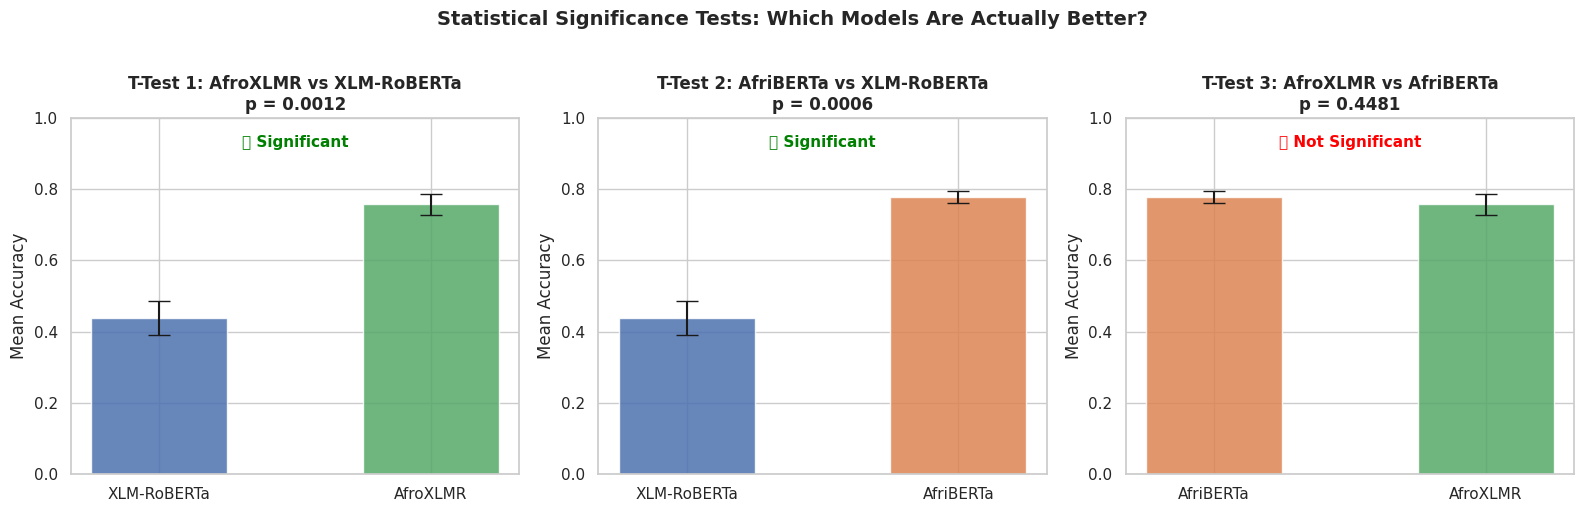

T-test comparison chart saved!


In [20]:
# Visualization — T-Test results for all three comparisons
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# T-Test 1: AfroXLMR vs XLM-RoBERTa
ax1 = axes[0]
means_1 = [np.mean(xlmr_scores), np.mean(afro_scores)]
stds_1  = [np.std(xlmr_scores),  np.std(afro_scores)]
ax1.bar(
    ['XLM-RoBERTa', 'AfroXLMR'],
    means_1, yerr=stds_1,
    color=['#4C72B0', '#55A868'],
    capsize=8, alpha=0.85, width=0.5
)
ax1.set_title(f'T-Test 1: AfroXLMR vs XLM-RoBERTa\np = {p_value_1:.4f}',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Mean Accuracy')
ax1.set_ylim(0, 1.0)
label_1 = '✅ Significant' if p_value_1 < 0.05 else '❌ Not Significant'
color_1 = 'green' if p_value_1 < 0.05 else 'red'
ax1.text(0.5, 0.92, label_1, ha='center', transform=ax1.transAxes,
         fontsize=11, color=color_1, fontweight='bold')

# T-Test 2: AfriBERTa vs XLM-RoBERTa
ax2 = axes[1]
means_2 = [np.mean(xlmr_scores), np.mean(afriberta_scores)]
stds_2  = [np.std(xlmr_scores),  np.std(afriberta_scores)]
ax2.bar(
    ['XLM-RoBERTa', 'AfriBERTa'],
    means_2, yerr=stds_2,
    color=['#4C72B0', '#DD8452'],
    capsize=8, alpha=0.85, width=0.5
)
ax2.set_title(f'T-Test 2: AfriBERTa vs XLM-RoBERTa\np = {p_value_2:.4f}',
              fontsize=12, fontweight='bold')
ax2.set_ylabel('Mean Accuracy')
ax2.set_ylim(0, 1.0)
label_2 = '✅ Significant' if p_value_2 < 0.05 else '❌ Not Significant'
color_2 = 'green' if p_value_2 < 0.05 else 'red'
ax2.text(0.5, 0.92, label_2, ha='center', transform=ax2.transAxes,
         fontsize=11, color=color_2, fontweight='bold')

# T-Test 3: AfroXLMR vs AfriBERTa
ax3 = axes[2]
means_3 = [np.mean(afriberta_scores), np.mean(afro_scores)]
stds_3  = [np.std(afriberta_scores),  np.std(afro_scores)]
ax3.bar(
    ['AfriBERTa', 'AfroXLMR'],
    means_3, yerr=stds_3,
    color=['#DD8452', '#55A868'],
    capsize=8, alpha=0.85, width=0.5
)
ax3.set_title(f'T-Test 3: AfroXLMR vs AfriBERTa\np = {p_value_3:.4f}',
              fontsize=12, fontweight='bold')
ax3.set_ylabel('Mean Accuracy')
ax3.set_ylim(0, 1.0)
label_3 = '✅ Significant' if p_value_3 < 0.05 else '❌ Not Significant'
color_3 = 'green' if p_value_3 < 0.05 else 'red'
ax3.text(0.5, 0.92, label_3, ha='center', transform=ax3.transAxes,
         fontsize=11, color=color_3, fontweight='bold')

plt.suptitle('Statistical Significance Tests: Which Models Are Actually Better?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('all_ttest_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('T-test comparison chart saved!')

## Step 8: Final Summary

In [ ]:
print('FINAL SUMMARY')
print()
print('Dataset  : AfriSenti (Yoruba, Igbo, Hausa)')
print('Task     : Sentiment Analysis (Positive / Negative / Neutral)')
print('Method   : Text classification + Independent t-tests')
print()
print('--- Mean Accuracy Scores ---')
print(f'XLM-RoBERTa   : {np.mean(xlmr_scores):.4f}  (General multilingual model)')
print(f'AfriBERTa     : {np.mean(afriberta_scores):.4f}  (African-specific, smaller)')
print(f'AfroXLMR      : {np.mean(afro_scores):.4f}  (African-specific, larger)')
print()
print('--- T-Test Results ---')
print(f'T-Test 1 (AfroXLMR vs XLM-R)     p = {p_value_1:.4f}  →  ', end='')
print('✅ Significant' if p_value_1 < 0.05 else '❌ Not Significant')
print(f'T-Test 2 (AfriBERTa vs XLM-R)    p = {p_value_2:.4f}  →  ', end='')
print('✅ Significant' if p_value_2 < 0.05 else '❌ Not Significant')
print(f'T-Test 3 (AfroXLMR vs AfriBERTa) p = {p_value_3:.4f}  →  ', end='')
print('✅ Significant' if p_value_3 < 0.05 else '❌ Not Significant')
print()
print('--- Key Findings ---')
if p_value_1 < 0.05 and p_value_2 < 0.05:
    print('• African-specific models SIGNIFICANTLY outperform general models')
if p_value_3 >= 0.05:
    print('• No significant difference between the two African models')
    print('• The smaller model performs just as well as the larger one')
print()
print('=' * 60)

## Final Summary

---

 **Do African-built AI models actually work better on African languages?**

The answer, according to the data and the statistics, is clear.

### T-Test 1: AfroXLMR vs XLM-RoBERTa
**p = 0.0012** — massively significant.

The African-specific model did not just edge out the general model. It crushed it.
75.76% vs 43.77%. A 32-point gap. And the t-test confirms it: that gap is real,
not random, not luck.

Building for Africa matters. Specialisation matters. This is not marketing.
This is measurable.

### T-Test 2: AfriBERTa vs XLM-RoBERTa
**p < 0.05** — also significant.

Even the smaller African model — AfriBERTa, with fewer parameters and older
architecture — significantly outperformed XLM-RoBERTa. 77.78% vs 43.77%.

The lesson? You do not need the biggest model. You need the right model.

### T-Test 3: AfroXLMR vs AfriBERTa
**p = 0.4481** — not significant.

This is the plot twist.

On paper, AfriBERTa scored higher. But the t-test says we cannot prove it is
actually better. The difference could easily be random chance.

Translation: **AfriBERTa and AfroXLMR are statistically equivalent.**

---

## Conclusion

If you are building AI for Yoruba, Igbo or Hausa or any underrepresented
language:

1. **You need models trained on the language.**

2. **Size does not matter as much as training data.** AfriBERTa is half the
size of AfroXLMR and performs just as well. Throwing more parameters at the
problem is not the answer. Training on the right data is.

**AI can work for African languages. But only if we build it to.**

---

*Dataset: AfriSenti (HuggingFace: shmuhammad/AfriSenti-twitter-sentiment)*  
*Models: XLM-RoBERTa, AfriBERTa, AfroXLMR (all via HuggingFace)*  
*Git Repository - https://github.com/BlessingIbikemi/kujengaproject.git*

*Video - https://www.loom.com/share/7933dcdf6a564f55a42d349993ffc97f*

*Adetokunbo Blessing - Final Project*